# Background

**FreshMart** merupakan supermarket yang menjual 6 kategori produk - **Wine, Fruits, Meat, Fish, Sweets, dan Gold** kepada **2.240** pelanggan dengan karakterstik demografis yang beragam. Meskipun data pelanggan dan transaksi telah tersedia, Product Manager masih **menghadapi kendala dalam menentukan strategi pemasaran yang tepat** karena promosi masih dilakukan secara umum tanpa mengetahui preferensi tiap segmen pelanggan.

Selain itu, perusahaan **belum mengetahui produk mana yang paling menghasilkan revenue serta faktor demografis apa yang memengaruhi pola pembelian pelanggan**. Kondisi ini menyebabkan strategi promosi dan pengambilan keputusan bisnis belum optimal. Oleh karena itu, diperlukan analisis segmentasi pelanggan untuk memahami pola pembelian berdasarkan karakteristik pelanggan sehingga strategi bisnis dapat lebih tepat sasaran.

## Research Question

**"Produk mana yang memiliki performa terbaik dan terburuk, dan bagaimana karakteristik pelanggan yang membeli masing-masing kategori produk tersebut?"**

Untuk menjawab hal tersebut, kita perlu mengidentifikasi :

**Product Performance**
1. Kategori produk mana yang memiliki total penjualan tertinggi dan terendah?
2. Bagaimana tren pengeluaran per produk berdasarkan waktu enrollment pelanggan?

**Segmentasi Pelanggan per Produk**
1. Apakah tingkat pendapatan (income) mempengaruhi penjualan untuk tiap kategori produk?
2. Apakah pelanggan dengan anak vs tanpa anak memiliki preferensi produk yang berbeda?
3. Apakah tingkat pendidikan pelanggan berpengaruh terhadap kategori produk yang dibeli?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Data Understanding and Preparation

## Load Dataset

In [2]:
df = pd.read_csv('Supermarket Customers.csv', sep='\t')
print(f'Jumlah baris dan kolom di dataset df adalah {df.shape}')
df.head()

Jumlah baris dan kolom di dataset df adalah (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Cek 5 baris terakhir

In [3]:
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


## Cek tipe data dan missing values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Ringkasan nilai untuk tiap kolom

In [5]:
pd.set_option('display.max_colwidth', None)
list_item= []
for col in df.columns:
    list_item.append([col, df[col].nunique(), df[col].unique()])
tabel_desc = pd.DataFrame(
    columns =['column_name', 'number_of_unique', 'unique_value'],
    data = list_item
)
tabel_desc

,column_name,number_of_unique,unique_value
0,ID,2240,"[5524, 2174, 4141, 6182, 5324, 7446, 965, 6177, 4855, 5899, 1994, 387, 2125, 8180, 2569, 2114, 9736, 4939, 6565, 2278, 9360, 5376, 1993, 4047, 1409, 7892, 2404, 5255, 9422, 1966, 6864, 3033, 5710, 7373, 8755, 10738, 4339, 10755, 8595, 2968, 8601, 503, 8430, 7281, 2139, 1371, 9909, 7286, 7244, 6566, 8614, 4114, 1331, 2225, 9381, 6260, 10383, 7437, 8557, 8375, 6853, 3076, 1012, 6518, 4137, 8082, 1386, 9369, 4477, 1357, 1402, 10629, 6312, 8132, 1050, 5846, 1859, 7503, 10401, 1618, 3332, 2261, 5346, 4119, 535, 5268, 273, 4452, 8504, 771, 8996, 9235, 5798, 11178, 2230, 7516, 7247, 11100, 4646, 3037, ...]"
1,Year_Birth,59,"[1957, 1954, 1965, 1984, 1981, 1967, 1971, 1985, 1974, 1950, 1983, 1976, 1959, 1952, 1987, 1946, 1980, 1949, 1982, 1979, 1951, 1969, 1986, 1989, 1963, 1970, 1973, 1943, 1975, 1996, 1968, 1964, 1977, 1978, 1955, 1966, 1988, 1948, 1958, 1972, 1960, 1945, 1991, 1962, 1953, 1961, 1956, 1992, 1900, 1893, 1990, 1947, 1899, 1993, 1994, 1941, 1944, 1995, 1940]"
2,Education,5,"[Graduation, PhD, Master, Basic, 2n Cycle]"
3,Marital_Status,8,"[Single, Together, Married, Divorced, Widow, Alone, Absurd, YOLO]"
4,Income,1974,"[58138.0, 46344.0, 71613.0, 26646.0, 58293.0, 62513.0, 55635.0, 33454.0, 30351.0, 5648.0, nan, 7500.0, 63033.0, 59354.0, 17323.0, 82800.0, 41850.0, 37760.0, 76995.0, 33812.0, 37040.0, 2447.0, 58607.0, 65324.0, 40689.0, 18589.0, 53359.0, 38360.0, 84618.0, 10979.0, 38620.0, 40548.0, 46610.0, 68657.0, 49389.0, 67353.0, 23718.0, 42429.0, 48948.0, 80011.0, 20559.0, 21994.0, 79941.0, 41728.0, 72550.0, 65486.0, 79143.0, 35790.0, 82582.0, 66373.0, 82384.0, 70287.0, 27938.0, 55954.0, 75777.0, 66653.0, 61823.0, 67680.0, 70666.0, 25721.0, 32474.0, 88194.0, 69096.0, 74854.0, 66991.0, 65031.0, 60631.0, 28332.0, 40246.0, 75251.0, 75825.0, 26326.0, 56046.0, 29760.0, 26304.0, 23559.0, 81361.0, 29440.0, 36138.0, 50388.0, 79593.0, 54178.0, 42394.0, 23626.0, 30096.0, 47916.0, 51813.0, 78497.0, 50150.0, 47823.0, 34554.0, 85693.0, 65846.0, 87195.0, 24594.0, 49096.0, 52413.0, 38557.0, 89058.0, 77298.0, ...]"
5,Kidhome,3,"[0, 1, 2]"
6,Teenhome,3,"[0, 1, 2]"
7,Dt_Customer,663,"[04-09-2012, 08-03-2014, 21-08-2013, 10-02-2014, 19-01-2014, 09-09-2013, 13-11-2012, 08-05-2013, 06-06-2013, 13-03-2014, 15-11-2013, 10-10-2012, 24-11-2012, 24-12-2012, 31-08-2012, 28-03-2013, 03-11-2012, 08-08-2012, 06-01-2013, 23-12-2012, 11-01-2014, 18-03-2013, 02-01-2013, 27-05-2013, 20-02-2013, 31-05-2013, 22-11-2013, 22-05-2014, 11-05-2013, 29-10-2012, 29-08-2013, 31-12-2013, 02-09-2013, 11-02-2014, 01-02-2013, 29-04-2013, 12-03-2013, 05-11-2013, 02-10-2013, 28-06-2014, 09-11-2012, 24-05-2013, 01-01-2014, 08-11-2012, 12-05-2014, 11-08-2012, 07-06-2014, 12-06-2013, 19-11-2012, 02-04-2013, 28-04-2014, 17-06-2013, 03-03-2014, 04-07-2013, 07-09-2012, 18-02-2013, 11-06-2013, 06-12-2013, 21-05-2013, 11-05-2014, 19-03-2014, 27-09-2013, 08-04-2013, 11-09-2012, 14-09-2012, 17-03-2013, 05-04-2013, 30-04-2014, 19-12-2012, 27-08-2012, 12-10-2012, 04-09-2013, 29-08-2012, 23-06-2013, 03-07-2013, 25-02-2014, 11-08-2013, 16-07-2013, 28-05-2014, 21-01-2014, 27-05-2014, 23-11-2013, 23-03-2014, 24-05-2014, 22-11-2012, 11-04-2013, 01-12-2013, 20-06-2013, 23-07-2013, 30-03-2014, 20-04-2013, 17-05-2013, 08-05-2014, 10-12-2013, 24-09-2013, 02-02-2013, 07-12-2012, 02-11-2013, 10-11-2012, 25-06-2014, ...]"
8,Recency,100,"[58, 38, 26, 94, 16, 34, 32, 19, 68, 11, 59, 82, 53, 23, 51, 20, 91, 86, 41, 42, 63, 0, 69, 89, 4, 96, 56, 31, 8, 55, 37, 76, 99, 3, 88, 80, 72, 24, 92, 39, 29, 2, 54, 57, 30, 12, 18, 75, 90, 1, 25, 40, 9, 87, 5, 95, 48, 70, 79, 45, 84, 44, 43, 35, 15, 17, 46, 27, 74, 85, 65, 13, 83, 10, 21, 61, 73, 47, 36, 49, 28, 64, 98, 78, 77, 81, 14, 52, 93, 50, 60, 66, 97, 62, 6, 33, 67, 22, 71, 7]"
9,MntWines,776,"[635, 11, 426, 173, 520, 235, 76, 14, 28, 5, 6, 194, 233, 3, 1006, 53, 84, 1012, 4, 86, 1, 867, 384, 270, 36, 684, 8, 112, 110, 96, 482, 40, 702, 55, 437, 421, 13, 9, 81, 123, 48, 826, 245, 650, 12, 510, 32

Secara umum, kita bisa melihat bahwa:

- Dataset Supermarket Customers memiliki **29 kolom dan 2.240 baris**
- Kolom `Income` memiliki data kosong yang diwakili dengan nilai NaN. Kolom ini akan diisi dengan nilai **median** karena lebih robust terhadap outlier dibanding mean.
- Kolom `ID` berisikan id unik untuk tiap pelanggan, sehingga tidak relevan dalam analisis.
- Kolom `Dt_Customer` memiliki tipe data **object**, padahal seharusnya bertipe **datetime**. Kolom ini perlu dikonversi agar bisa diekstrak informasi bulan dan tahunnya.
- Kolom `Year_Birth` memiliki beberapa nilai yang menghasilkan usia tidak wajar (di atas 90 tahun) jika dihitung dari tahun 2024. Data ini akan dihapus sebagai outlier.
- Kolom `Marital_Status` memiliki nilai yang perlu dicermati, seperti `Alone`, `Absurd`, dan `YOLO` yang kemungkinan perlu digabungkan atau dihapus.
- Beberapa kolom akan digunakan untuk membuat **kolom turunan** baru guna memudahkan analisis, yaitu:
  * `Age` → dihitung dari `Year_Birth`
  * `Total_Spending` → jumlah dari semua kolom `Mnt`
  * `Total_Children` → jumlah dari `Kidhome` + `Teenhome`
  * `Has_Children` → kategori ada/tidak ada anak
  * `Income_Segment` → segmentasi income menjadi Low, Medium, High
  * `Enrollment_Year` → tahun enrollment tiap pelanggan

## Cek missing value

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

## Cek duplikat

In [7]:
df.duplicated().sum()

np.int64(0)

## Cek anomali per kolom

In [8]:
# Kolom Marital_Status

print(df['Marital_Status'].value_counts())

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


In [9]:
# Kolom Education

print(df['Education'].value_counts())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


In [10]:
# Kolom Income

# Cek apakah ada nilai 0 atau negatif
print(f'Income = 0 : {(df["Income"] == 0).sum()}')
print(f'Income < 0 : {(df["Income"] < 0).sum()}')
print(f'Income min : {df["Income"].min():,.0f}')
print(f'Income max : {df["Income"].max():,.0f}')

Income = 0 : 0
Income < 0 : 0
Income min : 1,730
Income max : 666,666


In [11]:
# Kolom Dt_Customer

# Cek format tanggal
print(df['Dt_Customer'].dtype)
print(df['Dt_Customer'].head(10))

object
0    04-09-2012
1    08-03-2014
2    21-08-2013
3    10-02-2014
4    19-01-2014
5    09-09-2013
6    13-11-2012
7    08-05-2013
8    06-06-2013
9    13-03-2014
Name: Dt_Customer, dtype: object


In [12]:
# Cek nilai negatif kolom produk

for col in ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f'{col}: {neg} nilai negatif')
    else:
        print(f'{col}: ok')       

MntWines: ok
MntFruits: ok
MntMeatProducts: ok
MntFishProducts: ok
MntSweetProducts: ok
MntGoldProds: ok


## Statistik deskriptif

In [13]:
display(df.describe(), df.describe(include='object'))

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


## Cek outlier dengan Boxplot

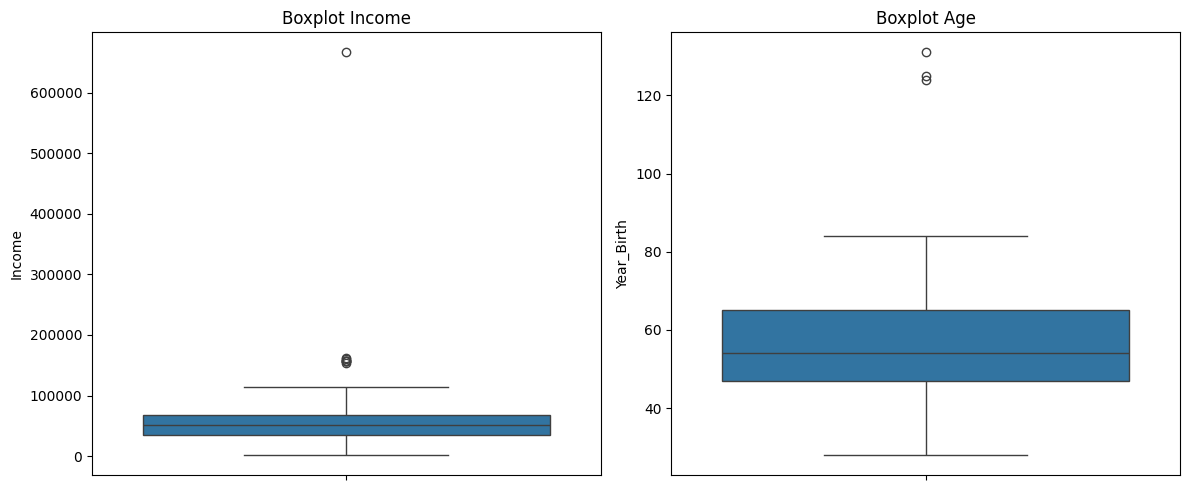

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(df['Income'], ax=axes[0])
axes[0].set_title('Boxplot Income')

sns.boxplot(df['Age'] if 'Age' in df.columns else 2024 - df['Year_Birth'], ax=axes[1])
axes[1].set_title('Boxplot Age')

plt.tight_layout()
plt.show()

Dari hasil boxplot di atas, kita bisa melihat bahwa:

* Kolom `Income` memiliki **1 outlier ekstrem** dengan nilai >600.000 
yang jauh di atas rentang normal pelanggan lainnya. Data ini akan dihapus 
agar tidak mempengaruhi hasil analisis.
* kolom `Age` memiliki **2 outlier** dengan usia di atas 120 tahun yang jelas 
tidak wajar dan tidak mungkin terjadi. Kedua data ini akan dihapus dari dataset.

Penanganan kedua outlier tersebut akan dilakukan pada tahap **Data Preparation**.

## Data Preparation

### Handle missing value Income

In [15]:
df['Income'] = df['Income'].fillna(df['Income'].median())
print(f'Missing value Income setelah dihandle: {df["Income"].isnull().sum()}')

Missing value Income setelah dihandle: 0


### Konversi tipe data

In [16]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)
print(f'Tipe data Dt_Customer: {df["Dt_Customer"].dtype}')

Tipe data Dt_Customer: datetime64[ns]


### Handle anomali Marital Status

In [17]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Together' : 'Married',
    'Alone'    : 'Single',
    'Absurd'   : 'Single',
    'YOLO'     : 'Single'
})
print(df['Marital_Status'].value_counts())

Marital_Status
Married     1444
Single       487
Divorced     232
Widow         77
Name: count, dtype: int64


### Handle anomali Education

In [18]:
df['Education'] = df['Education'].replace({
    '2n Cycle' : 'Diploma'
})
print(df['Education'].value_counts())

Education
Graduation    1127
PhD            486
Master         370
Diploma        203
Basic           54
Name: count, dtype: int64


### Menambah kolom baru (Featrure Engineering)

- Age → dihitung dari Year_Birth
- Total_Spending → jumlah dari semua kolom Mnt
- Total_Children → jumlah dari Kidhome + Teenhome
- Has_Children → kategori ada/tidak ada anak
- Income_Segment → segmentasi income menjadi Low, Medium, High
- Enrollment_Year → tahun enrollment tiap pelanggan

In [19]:
# Tahun terakhir enrollment pelanggan
tahun_referensi = df['Dt_Customer'].dt.year.max()

# Membuat kolom Age
df['Age'] = tahun_referensi - df['Year_Birth']

# Membuat kolom Total Spending
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                            'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

# Membuat kolom Total Children
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Membuat kolom Has Children
df['Has_Children']   = df['Total_Children'].apply(
    lambda x: 'Has Children' if x > 0 else 'No Children'
)

# Membuat kolom Income Segment
df['Income_Segment'] = pd.cut(df['Income'],
                              bins=[0, 30000, 60000, 150000],
                              labels=['Low', 'Medium', 'High'])

# Membuat kolom baru berisi tahun enrollment tiap pelanggan
df['Enrollment_Year'] = df['Dt_Customer'].dt.year

### Menghapus Outlier

In [20]:
Q1_income  = df['Income'].quantile(0.25)
Q3_income  = df['Income'].quantile(0.75)
IQR_income = Q3_income - Q1_income
batas_atas_income = Q3_income + 1.5 * IQR_income

df = df[(df['Income'] <= batas_atas_income) & (df['Age'] <= 90)]

In [21]:
print('Data preparation selesai!')
print(f'Shape akhir: {df.shape}')
df.head()

Data preparation selesai!
Shape akhir: (2229, 35)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending,Total_Children,Has_Children,Income_Segment,Enrollment_Year
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,57,1617,0,No Children,Medium,2012
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,60,27,2,Has Children,Medium,2014
2,4141,1965,Graduation,Married,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,49,776,0,No Children,High,2013
3,6182,1984,Graduation,Married,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,30,53,1,Has Children,Low,2014
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,33,422,1,Has Children,Medium,2014


Setelah dilakukan data cleaning dan preparation, dataset kini memiliki **2229 baris data dan 35 kolom**. Beberapa perubahan yang telah dilakukan :

- Mengisi missing value pada kolom `Income` dengan nilai median
- Mengkonversi kolom `Dt_Customer` ke tipe data datetime
- Menghapus outlier pada kolom `Age` (usia > 90 tahun) dan `Income`
- Menambahkan kolom baru: `Age`, `Total_Spending`, `Total_Children`, `Has_Children`, `Income_Segment` dan `Enrollment_Year`

# Data Analysis

## 1. Product Performance

### 1.1 Kategori produk mana yang memiliki total pengeluaran tertinggi dan terendah?

/var/folders/ph/8mmm7pys2874hjp6h1x7dslw0000gp/T/ipykernel_1842/2269538698.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


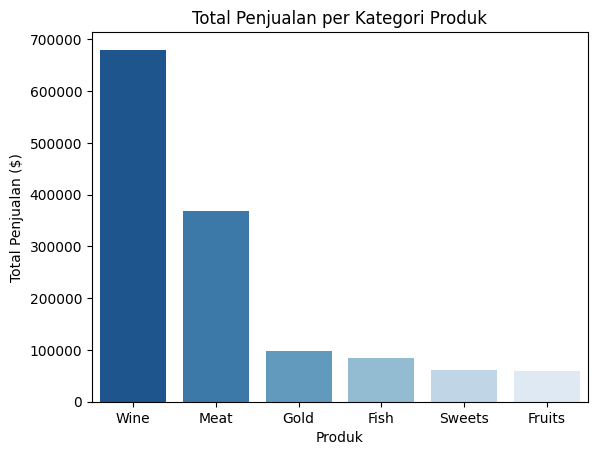

In [22]:
product_cols = ['MntWines','MntFruits','MntMeatProducts',
                'MntFishProducts','MntSweetProducts','MntGoldProds']
product_labels = ['Wine', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']

product_total = pd.DataFrame({
    'Produk': product_labels,
    'Total_Spending': df[product_cols].sum().values
}).sort_values('Total_Spending', ascending=False)

sns.barplot(
    data = product_total,
    x = 'Produk',
    y = 'Total_Spending',
    palette = 'Blues_r'
)
plt.title('Total Penjualan per Kategori Produk')
plt.ylabel('Total Penjualan ($)')
plt.show()

In [23]:
print(product_total)

   Produk  Total_Spending
0    Wine          679826
2    Meat          368418
5    Gold           98328
3    Fish           83905
4  Sweets           60543
1  Fruits           58731


Dari grafik di atas, kita bisa melihat bahwa:

* **Wine** adalah produk dengan total penjualan tertinggi, jauh melampaui produk lainnya
* **Meat** berada di posisi kedua sebagai produk dengan penjualan terbesar
* **Fruits** dan **Sweets** adalah produk dengan pengeluaran terendah, mengindikasikan bahwa kedua kategori ini kurang diminati pelanggan

### 1.2 Bagaimana tren pengeluaran per produk berdasarkan waktu enrollment pelanggan? 

In [24]:
print(df['Dt_Customer'].dt.year.unique())

[2012 2014 2013]


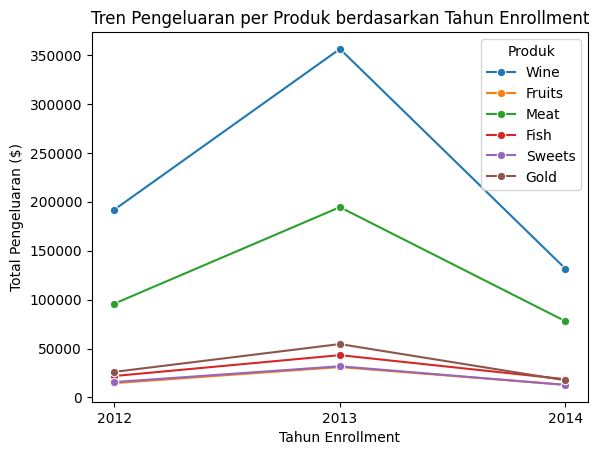

In [25]:
df['Enrollment_Year'] = df['Dt_Customer'].dt.year

trend = df.groupby('Enrollment_Year')[product_cols].sum().reset_index()
trend.columns = ['Enrollment_Year'] + product_labels

trend_melt = trend.melt(id_vars='Enrollment_Year', var_name='Produk', value_name='Total_Spending')

sns.lineplot(
    data=trend_melt, 
    x='Enrollment_Year', 
    y='Total_Spending', 
    hue='Produk', 
    marker='o'
)
plt.title('Tren Pengeluaran per Produk berdasarkan Tahun Enrollment')
plt.ylabel('Total Pengeluaran ($)')
plt.xlabel('Tahun Enrollment')
plt.xticks([2012, 2013, 2014])
plt.show()

In [26]:
print(trend)

   Enrollment_Year    Wine  Fruits    Meat   Fish  Sweets   Gold
0             2012  192014   14665   95955  21953   15781  26184
1             2013  356171   31093  194488  43288   31918  54583
2             2014  131641   12973   77975  18664   12844  17561


Dari grafik tren di atas, kita bisa melihat bahwa:

* Pengeluaran untuk **Wine** konsisten menjadi yang tertinggi di setiap tahun enrollment
* Terdapat fluktuasi pengeluaran di beberapa kategori produk seiring bertambahnya 
tahun enrollment pelanggan

## 2. Segmentasi Pelanggan per Produk

### 2.1 Apakah tingkat pendapatan (income) mempengaruhi penjualan tiap kategori produk?

* **H0:** Tidak ada perbedaan rata-rata penjualan produk antar kelompok Income Segment
* **H1:** Terdapat perbedaan rata-rata penjualan produk antar kelompok Income Segment

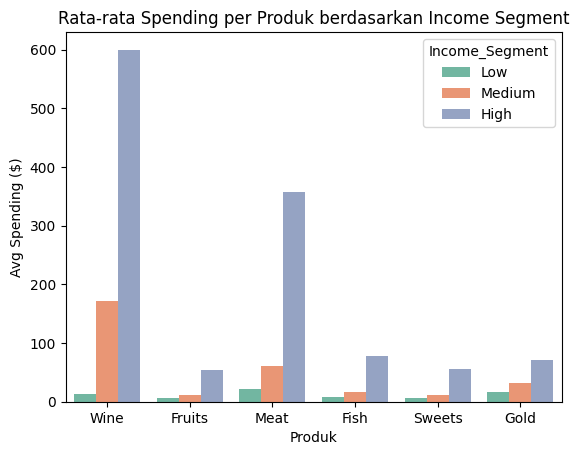

In [27]:
income_product = df.groupby('Income_Segment', observed=True)[product_cols].mean().reset_index()
income_product.columns = ['Income_Segment'] + product_labels

income_melt = income_product.melt(id_vars='Income_Segment', var_name='Produk', value_name='Avg_Spending')

sns.barplot(data=income_melt, x='Produk', y='Avg_Spending', hue='Income_Segment', palette='Set2')
plt.title('Rata-rata Spending per Produk berdasarkan Income Segment')
plt.ylabel('Avg Spending ($)')
plt.show()

In [28]:
income_product = df.groupby('Income_Segment', observed=True)[product_cols].mean().reset_index()
income_product.columns = ['Income_Segment'] + product_labels
print(income_product)

  Income_Segment        Wine     Fruits        Meat       Fish     Sweets  \
0            Low   13.781081   5.745946   21.462162   8.010811   6.189189   
1         Medium  171.480545  10.678988   61.634241  16.209144  11.403696   
2           High  599.813478  54.906137  357.541516  77.350181  55.992780   

        Gold  
0  16.994595  
1  32.442607  
2  70.624549  


In [29]:
# Cek Normalitas

from scipy.stats import normaltest

for col, label in zip(product_cols, product_labels):
    stat, pvalue = normaltest(df[col])                    
    if pvalue > 0.05:
        result = 'Normal' 
    else: 
        result = 'Tidak Normal' 
    print(f'{label:10} | p={pvalue:.4f} | {result}')    

Wine       | p=0.0000 | Tidak Normal
Fruits     | p=0.0000 | Tidak Normal
Meat       | p=0.0000 | Tidak Normal
Fish       | p=0.0000 | Tidak Normal
Sweets     | p=0.0000 | Tidak Normal
Gold       | p=0.0000 | Tidak Normal


Dari hasil cek normalitas, angka pvalue < 0.05 maka hasilnya **Tidak Normal** sehingga kita menggunakan Uji Statistik **Kruskal-Wallis**

In [30]:
# Uji Statistik: Kruskal-Wallis

from scipy.stats import kruskal
print("=== Kruskal-Wallis: Income Segment vs Each Product ===")
for col, label in zip(product_cols, product_labels):
    groups = [group[col].values for _, group in df.groupby('Income_Segment', observed=True)]
    stat, pvalue = kruskal(*groups)
    if pvalue < 0.05:
        result = f'Tolak H0 → Terdapat perbedaan rata-rata penjualan {label} antar kelompok Income Segment'
    else:
        result = f'Gagal Tolak H0 → Tidak ada perbedaan rata-rata penjualan {label} antar kelompok Income Segment'
    print(f'{label:10} | p={pvalue:.4f} | {result}')

=== Kruskal-Wallis: Income Segment vs Each Product ===
Wine       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata penjualan Wine antar kelompok Income Segment
Fruits     | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata penjualan Fruits antar kelompok Income Segment
Meat       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata penjualan Meat antar kelompok Income Segment
Fish       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata penjualan Fish antar kelompok Income Segment
Sweets     | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata penjualan Sweets antar kelompok Income Segment
Gold       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata penjualan Gold antar kelompok Income Segment


Dari grafik dan uji statistik Kruskal-Wallis di atas, kita bisa melihat bahwa:

* Pelanggan dengan income **High** memiliki rata-rata pengeluaran tertinggi 
di hampir semua kategori produk, terutama **Wine** dan **Meat**
* Pelanggan dengan income **Low** cenderung memiliki pengeluaran yang sangat 
rendah di semua kategori produk
* Karena p-value < 0.05 maka **Tolak H0** → income segment berpengaruh 
**signifikan** terhadap pengeluaran di semua kategori produk

### 2.2 Apakah pelanggan dengan anak vs tanpa anak memiliki preferensi produk yang berbeda?

* **H0:** Tidak ada perbedaan rata-rata pengeluaran produk antara pelanggan 
dengan anak dan tanpa anak
* **H1:** Terdapat perbedaan rata-rata pengeluaran produk antara pelanggan 
dengan anak dan tanpa anak

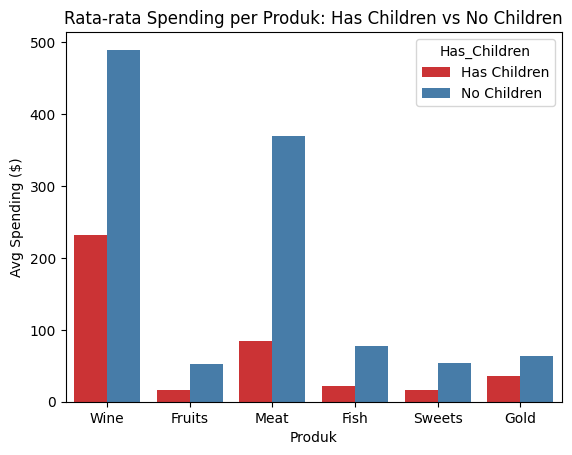

In [31]:
children_product = df.groupby('Has_Children')[product_cols].mean().reset_index()
children_product.columns = ['Has_Children'] + product_labels

children_melt = children_product.melt(id_vars='Has_Children', var_name='Produk', value_name='Avg_Spending')

sns.barplot(data=children_melt, x='Produk', y='Avg_Spending', hue='Has_Children', palette='Set1')
plt.title('Rata-rata Spending per Produk: Has Children vs No Children')
plt.ylabel('Avg Spending ($)')
plt.show()

In [32]:
children_product = df.groupby('Has_Children')[product_cols].mean().reset_index()
children_product.columns = ['Has_Children'] + product_labels
print(children_product)

   Has_Children        Wine     Fruits        Meat       Fish     Sweets  \
0  Has Children  231.666040  15.970551   84.338972  22.050752  16.766917   
1   No Children  489.868878  52.515008  369.372828  76.954186  53.369668   

        Gold  
0  36.110276  
1  64.290679  


* Berdasarkan uji normalitas yang telah dilakukan sebelumnya, 
seluruh kolom produk menunjukkan distribusi **tidak normal** (p-value < 0.05). Oleh karena itu, uji Mann-Whitney digunakan sebagai uji nonparametrik untuk membandingkan 2 kelompok (Has Children vs No Children).

In [33]:
# Uji Statistik: Mann-Whitney

from scipy.stats import mannwhitneyu
print("=== Mann-Whitney: Has Children vs No Children per Product ===")
for col, label in zip(product_cols, product_labels):
    g1 = df[df['Has_Children'] == 'Has Children'][col]
    g2 = df[df['Has_Children'] == 'No Children'][col]
    stat, pvalue = mannwhitneyu(g1, g2)
    if pvalue < 0.05:
        result = f'Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antara pelanggan dengan anak dan tanpa anak'
    else:
        result = f'Gagal Tolak H0 → Tidak ada perbedaan rata-rata pengeluaran produk antara pelanggan dengan anak dan tanpa anak'
    print(f'{label:10} | p={pvalue:.4f} | {result}')

=== Mann-Whitney: Has Children vs No Children per Product ===
Wine       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antara pelanggan dengan anak dan tanpa anak
Fruits     | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antara pelanggan dengan anak dan tanpa anak
Meat       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antara pelanggan dengan anak dan tanpa anak
Fish       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antara pelanggan dengan anak dan tanpa anak
Sweets     | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antara pelanggan dengan anak dan tanpa anak
Gold       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antara pelanggan dengan anak dan tanpa anak


Dari grafik dan uji statistik Mann-Whitney di atas, kita bisa melihat bahwa:

* Pelanggan **tanpa anak (No Children)** memiliki rata-rata penjualan 
lebih tinggi di **semua kategori produk** tanpa terkecuali, terutama 
**Wine** dan **Meat**
* Pelanggan **dengan anak (Has Children)** memiliki rata-rata penjualan 
yang lebih rendah di semua kategori, dengan **Wine** dan 
**Meat** tetap menjadi produk dengan penjualan tertinggi di segmen ini
* Perbedaan paling signifikan terlihat pada kategori **Wine** dan **Meat**, 
sedangkan kategori **Fruits, Fish, Sweets, dan Gold** memiliki perbedaan 
yang lebih kecil antar kedua segmen
* Karena p-value < 0.05 maka **Tolak H0** → terdapat perbedaan yang 
**signifikan** antara pelanggan dengan anak dan tanpa anak di semua 
kategori produk

### 2.3 Apakah tingkat pendidikan pelanggan berpengaruh terhadap kategori produk yang dibeli?

* **H0:** Tidak ada perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan
* **H1:** Terdapat perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan

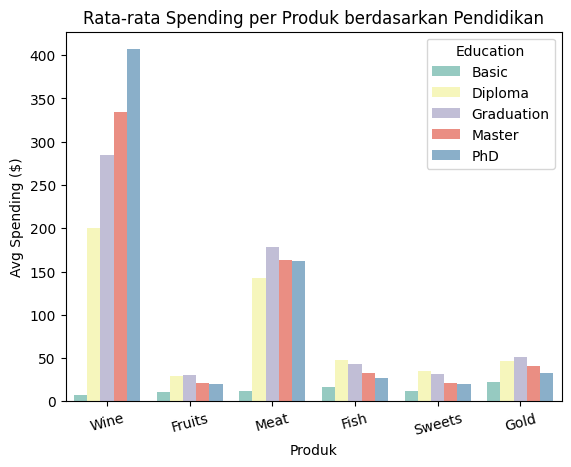

In [34]:
edu_product = df.groupby('Education')[product_cols].mean().reset_index()
edu_product.columns = ['Education'] + product_labels

edu_melt = edu_product.melt(id_vars='Education', var_name='Produk', value_name='Avg_Spending')

sns.barplot(data=edu_melt, x='Produk', y='Avg_Spending', hue='Education', palette='Set3')
plt.title('Rata-rata Spending per Produk berdasarkan Pendidikan')
plt.ylabel('Avg Spending ($)')
plt.xticks(rotation=15)
plt.show()

In [35]:
edu_product = df.groupby('Education')[product_cols].mean().reset_index()
edu_product.columns = ['Education'] + product_labels
print(edu_product)

    Education        Wine     Fruits        Meat       Fish     Sweets  \
0       Basic    7.240741  11.111111   11.444444  17.055556  12.111111   
1     Diploma  200.039801  29.213930  142.597015  47.885572  34.572139   
2  Graduation  285.017794  30.843416  178.416370  43.255338  31.448399   
3      Master  333.872629  21.710027  163.796748  32.181572  21.233062   
4         PhD  406.794179  19.916840  162.488565  26.746362  20.284823   

        Gold  
0  22.833333  
1  46.726368  
2  50.972420  
3  40.485095  
4  32.164241  


In [36]:
# Uji Statistik: Kruskal-Wallis

print("=== Kruskal-Wallis: Education vs Each Product ===")
for col, label in zip(product_cols, product_labels):
    groups = [group[col].values for _, group in df.groupby('Education')]
    stat, pval = kruskal(*groups)
    if pvalue < 0.05:
        result = f'Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan'
    else:
        result = f'Gagal Tolak H0 → Tidak ada perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan'
    print(f'{label:10} | p={pvalue:.4f} | {result}')

=== Kruskal-Wallis: Education vs Each Product ===
Wine       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan
Fruits     | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan
Meat       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan
Fish       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan
Sweets     | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan
Gold       | p=0.0000 | Tolak H0 → Terdapat perbedaan rata-rata pengeluaran produk antar kelompok tingkat pendidikan


Dari grafik dan uji statistik Kruskal-Wallis di atas, kita bisa melihat bahwa:

* Pelanggan dengan pendidikan **PhD dan Master** cenderung memiliki pengeluaran 
lebih tinggi untuk **Wine**
* Karena p-value < 0.05 maka **Tolak H0** → tingkat pendidikan berpengaruh 
**signifikan** terhadap pengeluaran di beberapa kategori produk

# Conclusion and Recommendation

## Kesimpulan

Berdasarkan analisis yang telah dilakukan terhadap data penjualan 
Supermarket FreshMart, berikut adalah temuan utama yang dapat disimpulkan:

**Product Performance:**
* **Wine** dan **Meat** adalah produk dengan total penjualan tertinggi 
dan konsisten menjadi produk unggulan di setiap tahun enrollment pelanggan
* **Fruits** dan **Sweets** adalah produk dengan total penjualan terendah 
di semua segmen pelanggan

**Segmentasi Pelanggan:**
* Pelanggan dengan income **High** memiliki rata-rata penjualan tertinggi 
di semua kategori produk, terutama **Wine** dan **Meat**. Hasil uji 
Kruskal-Wallis membuktikan bahwa income segment berpengaruh **signifikan** 
terhadap penjualan semua kategori produk
* Pelanggan **tanpa anak** membelanjakan lebih banyak di semua kategori 
produk dibanding pelanggan dengan anak, terutama pada **Wine** dan **Meat**. 
Hasil uji Mann-Whitney membuktikan perbedaan ini **signifikan** secara statistik
* Pelanggan dengan pendidikan **PhD dan Master** cenderung memiliki 
pengeluaran lebih tinggi untuk **Wine** dibanding tingkat pendidikan lainnya

## Rekomendasi

Berdasarkan temuan di atas, berikut rekomendasi yang dapat diberikan 
kepada Product Manager Supermarket:

**1. Pertahankan & Optimalkan Produk Unggulan**
* **Wine dan Meat** adalah produk dengan penjualan tertinggi — pertahankan 
ketersediaan stok dan kualitasnya
* Buat **bundling promo Wine + Meat** untuk meningkatkan penjualan kedua 
produk sekaligus

**2. Strategi untuk Produk dengan Penjualan Rendah**
* **Fruits dan Sweets** perlu mendapat perhatian khusus — evaluasi strategi 
pricing, packaging, dan penempatan produk di rak
* Buat **promo khusus** seperti diskon atau buy 1 get 1 untuk meningkatkan 
penjualan Fruits dan Sweets

**3. Targetkan Pelanggan Berdasarkan Segmen Income**
* Fokuskan promosi produk premium (**Wine dan Meat**) kepada pelanggan 
dengan income **High**
* Untuk pelanggan income **Low dan Medium**, tawarkan produk dengan 
harga lebih terjangkau atau promo diskon

**4. Strategi Berdasarkan Status Keluarga**
* Pelanggan **tanpa anak** adalah segmen dengan penjualan tertinggi — 
jadikan segmen ini sebagai target utama kampanye produk premium
* Untuk pelanggan **dengan anak**, fokuskan promosi pada produk 
keluarga seperti **Fruits dan Sweets** dengan format family pack

**5. Strategi Berdasarkan Pendidikan**
* Pelanggan dengan pendidikan **PhD dan Master** memiliki preferensi 
tinggi terhadap **Wine** — pertimbangkan untuk menyediakan pilihan 
Wine premium untuk segmen ini

## Export Dataset

### Dataset 1

In [37]:
df.to_csv('cleaned_supermarket_customers.csv', index=False)

### Dataset 2

In [38]:
product_summary = pd.DataFrame({
    'Produk'   : ['Wine','Meat','Gold','Fish','Sweets','Fruits'],
    'Penjualan': [
        df['MntWines'].sum(),
        df['MntMeatProducts'].sum(),
        df['MntGoldProds'].sum(),
        df['MntFishProducts'].sum(),
        df['MntSweetProducts'].sum(),
        df['MntFruits'].sum()
    ]
})

product_summary.to_csv('Product_Summary.csv', index=False)
print(product_summary)

   Produk  Penjualan
0    Wine     679826
1    Meat     368418
2    Gold      98328
3    Fish      83905
4  Sweets      60543
5  Fruits      58731


In [39]:
product_summary = pd.read_csv('Product_Summary.csv')
print(product_summary)
print(product_summary.columns.tolist())

   Produk  Penjualan
0    Wine     679826
1    Meat     368418
2    Gold      98328
3    Fish      83905
4  Sweets      60543
5  Fruits      58731
['Produk', 'Penjualan']


### Dataset 3

In [40]:
# Export format long per pelanggan
df_renamed = df.copy()
df_renamed = df_renamed.rename(columns=dict(zip(product_cols, product_labels)))

df_long = df_renamed.melt(
    id_vars=['Income_Segment', 'Education', 'Has_Children', 'Enrollment_Year'],
    value_vars=product_labels,
    var_name='Product',
    value_name='Sales'
)

df_long.to_csv('Segmentation_Raw.csv', index=False)
print(f'Shape: {df_long.shape}')

Shape: (13374, 6)
